In [1]:
# ============================================================
# 0. ИМПОРТ БИБЛИОТЕК И ЗАГРУЗКА ДАННЫХ
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from google.colab import files
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Настройка стиля графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Загрузка файла
print("Загрузите файл bank.csv:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Чтение данных
df = pd.read_csv(file_name)

print(f"\nФайл {file_name} успешно загружен!")
print("Первые 5 строк датасета:")
display(df.head())

print("\nИнформация о данных:")
df.info()

Загрузите файл bank.csv:


Saving bank.csv to bank.csv

Файл bank.csv успешно загружен!
Первые 5 строк датасета:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


### Описание признаков датасета

**Демографические данные:**
* **age** — возраст клиента (числовой).
* **job** — тип занятости / профессия (категориальный).
* **marital** — семейное положение (категориальный).
* **education** — уровень образования (порядковый).

**Финансовая история:**
* **default** — наличие просрочки по кредиту (бинарный: yes/no).
* **balance** — баланс на банковском счете в евро (числовой).
* **housing** — наличие ипотеки (бинарный: yes/no).
* **loan** — наличие потребительского кредита (бинарный: yes/no).

**Данные о контактах:**
* **contact** — тип связи (сотовый, стационарный).
* **day** / **month** — день и месяц последнего контакта.
* **duration** — длительность разговора в секундах (числовой).
* **campaign** — количество контактов в текущей кампании.
* **pdays** — дней с прошлого контакта (-1 = не контактировали).
* **previous** — количество контактов до этой кампании.
* **poutcome** — результат прошлой кампании.

**Целевая переменная:**
* **deposit** — открыл ли клиент депозит (yes/no).

In [5]:
# ============================================================
# ЗАДАНИЕ 1. Типы шкал измерения
# ============================================================
print("\n" + "="*50)
print("ЗАДАНИЕ 1. Типы шкал измерения")
print("="*50)

scale_types = {
    'age': 'абсолютная',       'job': 'номинальная',
    'marital': 'номинальная',   'education': 'порядковая',
    'default': 'номинальная',   'balance': 'абсолютная',
    'housing': 'номинальная',   'loan': 'номинальная',
    'contact': 'номинальная',   'day': 'интервальная',
    'month': 'порядковая',      'duration': 'абсолютная',
    'campaign': 'абсолютная',   'pdays': 'абсолютная',
    'previous': 'абсолютная',   'poutcome': 'номинальная',
    'deposit': 'номинальная'
}

for col, scale in scale_types.items():
    print(f"{col:15} : {scale}")


print("\n--- Анализ метрик для разных шкал ---")

print("\nДля возраста (абсолютная шкала):")
print("- Среднее арифметическое имеет смысл.")
print("- Медиана имеет смысл.")
print("- Мода имеет смысл.")
print("Все три статистики математически корректны.")

print("\nДля образования (порядковая шкала):")
print("- Среднее арифметическое не имеет смысла.")
print("- Медиана имеет смысл (центральная категория).")
print("- Мода имеет смысл (самая частая категория).")
print("Математически корректны только мода и медиана (при упорядочении).")


ЗАДАНИЕ 1. Типы шкал измерения
age             : абсолютная
job             : номинальная
marital         : номинальная
education       : порядковая
default         : номинальная
balance         : абсолютная
housing         : номинальная
loan            : номинальная
contact         : номинальная
day             : интервальная
month           : порядковая
duration        : абсолютная
campaign        : абсолютная
pdays           : абсолютная
previous        : абсолютная
poutcome        : номинальная
deposit         : номинальная

--- Анализ метрик для разных шкал ---

Для возраста (абсолютная шкала):
- Среднее арифметическое имеет смысл.
- Медиана имеет смысл.
- Мода имеет смысл.
Все три статистики математически корректны.

Для образования (порядковая шкала):
- Среднее арифметическое не имеет смысла.
- Медиана имеет смысл (центральная категория).
- Мода имеет смысл (самая частая категория).
Математически корректны только мода и медиана (при упорядочении).


### ЗАДАНИЕ 1. Типы шкал измерения
1. Номинальная шкала
Это шкала наименований. Данные здесь — это просто категории или метки. Их нельзя сравнивать по принципу "больше/меньше", можно только сказать, равны они или нет.

2. Порядковая шкала
Здесь данные уже имеют естественный порядок, но расстояние между значениями не определено или не имеет смысла.

3. Интервальная шкала
Значения имеют порядок и равные интервалы между ними, но у этой шкалы нет «абсолютного нуля» (ноль не означает полное отсутствие признака).

4. Абсолютная шкала
Самый высокий уровень измерения. Есть порядок, равные интервалы и истинный ноль, который означает отсутствие измеряемой величины. С этими данными можно выполнять любые арифметические действия.


### ЗАДАНИЕ 2. Диагностика типа пропусков

**Выбранный признак:** `poutcome` (результат предыдущей маркетинговой кампании). Значение `unknown` мы трактуем как пропуск данных (клиент новый или данные не сохранились).

**1. Формулировка альтернативных гипотез:**
* **Гипотеза MCAR (Абсолютно случайные пропуски):** Факт того, что результат прошлой кампании неизвестен, не зависит ни от возраста, ни от баланса, ни от профессии клиента. Это техническая случайность.
* **Гипотеза MAR (Случайные пропуски, зависящие от наблюдаемых данных):** Пропуски можно объяснить другими колонками. Например, вероятность пропуска (`unknown`) выше у определенных профессий или сильно зависит от возраста/образования.
* **Гипотеза MNAR (Неслучайные пропуски):** Пропуск зависит от самого невидимого значения. Например, клиент грубо послал оператора, и тот, чтобы не портить статистику отказов (`failure`) - (неудача) , намеренно поставил `unknown`.

**2. План проверок:**
* **Для MCAR:** Проведем t-тест Стьюдента, чтобы проверить, отличается ли средний возраст людей с пропусками и без них. Построим Boxplot.
* **Для MAR:** Посмотрим долю пропусков в разрезе профессий (Barplot) и построим модель Логистической регрессии. Если ROC-AUC будет высоким, значит другие признаки "выдают" пропуск, и это MAR.
* **Для MNAR:** Прямая проверка невозможна, опишем логическое обоснование.


ЗАДАНИЕ 2. Диагностика типа пропусков

Выбран признак 'poutcome'. Значение 'unknown' считаем пропуском.
Доля пропусков ('unknown') в данных: 74.59%

--- 1. Проверка гипотезы MCAR ---
t-тест для возраста: p-value = 7.0976e-03
Вывод: Различия статистически значимы -> пропуск зависит от возраста. Это говорит ПРОТИВ гипотезы MCAR.

--- 2. Проверка гипотезы MAR ---

Доля пропусков по уровням профессий (топ-3):
job
student    0.602778
retired    0.686375
admin.     0.708396
Name: is_missing, dtype: float64


/tmp/ipykernel_8374/2518158857.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_missing', y='age', data=df, palette='Set2')


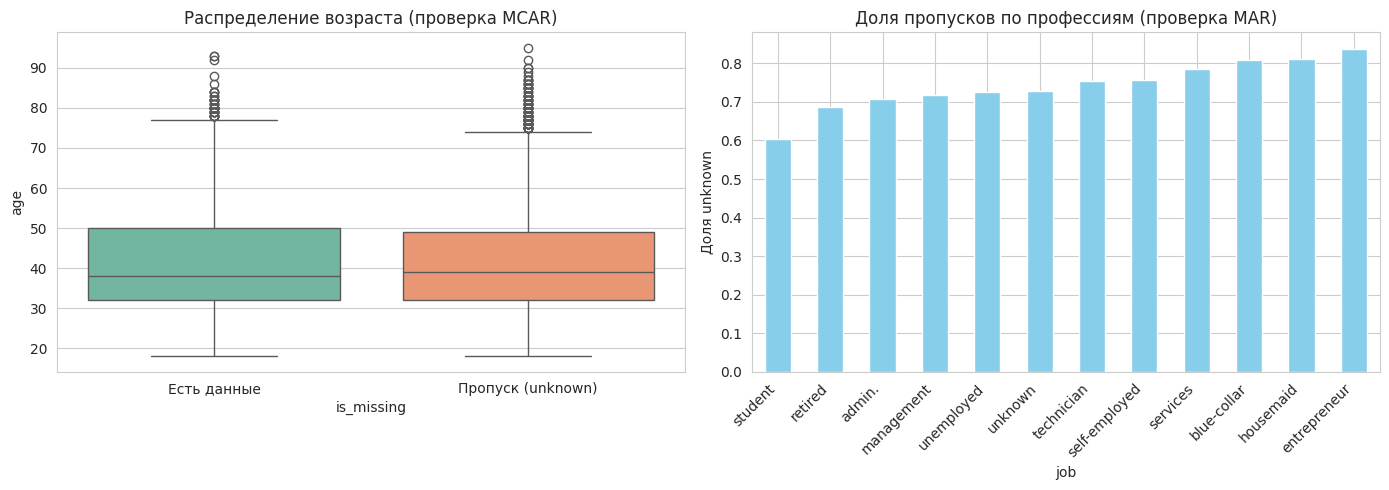


Обучаем модель логистической регрессии для предсказания пропуска...
ROC-AUC модели (качество предсказания пропуска): 0.584
Вывод: Модель слабая. Вероятно, пропуски ближе к MCAR.

--- 3. Оценка гипотезы MNAR ---
Прямая математическая проверка MNAR невозможна без привлечения внешних данных.
Однако мы можем логически допустить, что часть пропусков — это скрытые отказы (failure),
которые операторы не хотели фиксировать. Доказать это опираясь только на этот датасет нельзя.


In [9]:
# -------------------------------------
# ЗАДАНИЕ 2. Диагностика типа пропусков
# -------------------------------------
import pandas as pd
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*60)
print("ЗАДАНИЕ 2. Диагностика типа пропусков")
print("="*60)

# Выбранный признак
target_feature = 'poutcome'
print(f"\nВыбран признак '{target_feature}'. Значение 'unknown' считаем пропуском.")

missing_count = (df[target_feature] == 'unknown').sum()
total = len(df)
print(f"Доля пропусков ('unknown') в данных: {missing_count / total:.2%}")

# Создаем индикатор пропуска
df['is_missing'] = (df[target_feature] == 'unknown').astype(int)

# ------------------------------------------------------------
# 1. Проверка гипотезы MCAR
# ------------------------------------------------------------
print("\n--- 1. Проверка гипотезы MCAR ---")
age_known = df[df['is_missing'] == 0]['age']
age_unknown = df[df['is_missing'] == 1]['age']

t_stat, p_value = stats.ttest_ind(age_known, age_unknown, equal_var=False)
print(f"t-тест для возраста: p-value = {p_value:.4e}")

if p_value > 0.05:
    print("Вывод: Различий в возрасте нет -> гипотеза MCAR НЕ опровергнута.")
else:
    print("Вывод: Различия статистически значимы -> пропуск зависит от возраста. Это говорит ПРОТИВ гипотезы MCAR.")

# Визуализация для MCAR и MAR
plt.figure(figsize=(14, 5))

# Boxplot (MCAR)
plt.subplot(1, 2, 1)
sns.boxplot(x='is_missing', y='age', data=df, palette='Set2')
plt.xticks([0, 1], ['Есть данные', 'Пропуск (unknown)'])
plt.title('Распределение возраста (проверка MCAR)')

# ------------------------------------------------------------
# 2. Проверка гипотезы MAR
# ------------------------------------------------------------
print("\n--- 2. Проверка гипотезы MAR ---")
# Анализ по категориям (Профессия)
job_prop = df.groupby('job')['is_missing'].mean().sort_values()
print("\nДоля пропусков по уровням профессий (топ-3):")
print(job_prop.head(3))

# Barplot (MAR)
plt.subplot(1, 2, 2)
job_prop.plot(kind='bar', color='skyblue')
plt.title('Доля пропусков по профессиям (проверка MAR)')
plt.ylabel('Доля unknown')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Логистическая регрессия
print("\nОбучаем модель логистической регрессии для предсказания пропуска...")
X = pd.get_dummies(df[['age', 'balance', 'education', 'job', 'marital']], drop_first=True)
y = df['is_missing']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)
y_probs = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_probs)

print(f"ROC-AUC модели (качество предсказания пропуска): {auc:.3f}")
if auc > 0.65:
    print("Вывод: Модель обладает предсказательной силой. Пропуски зависят от других признаков, что подтверждает гипотезу MAR.")
else:
    print("Вывод: Модель слабая. Вероятно, пропуски ближе к MCAR.")

# ------------------------------------------------------------
# 3. Проверка гипотезы MNAR
# ------------------------------------------------------------
print("\n--- 3. Оценка гипотезы MNAR ---")
print("Прямая математическая проверка MNAR невозможна без привлечения внешних данных.")
print("Однако мы можем логически допустить, что часть пропусков — это скрытые отказы (failure),")
print("которые операторы не хотели фиксировать. Доказать это опираясь только на этот датасет нельзя.")

### ЗАДАНИЕ 3. Индикатор пропуска как источник информации

**1. Когда пропуск информативен?**
Факт пропуска несет информацию, если он **неслучаен** (MAR или MNAR). В нашем случае `unknown` в `poutcome` — это сигнал о том, что клиент является «новым».

**2. Почему значимость индикатора — сигнал плохой импутации?**
Значимость подтверждает, что пропуски содержательны. Грубая замена (средним или модой) «затирает» этот сигнал, заставляя модель использовать индикатор для исправления искажений.

**3. Примеры признаков:**
* **Полезен:** `poutcome` — позволяет выделить сегмент клиентов без истории контактов.
* **Бесполезен:** `age` — пропуски обычно являются случайными техническими ошибками (MCAR).
* **Опасен:** `balance` — использование индикатора может создать предвзятость в отношении скрытных клиентов.

---

**Вывод на основе анализа `poutcome`:**
Несмотря на то, что мы классифицировали пропуски в `poutcome` как близкие к **MCAR** (из-за низкого ROC-AUC = 0.584), создание индикатора пропуска для этой колонки остается **полезным**.

* **Почему полезен:** В данном датасете `unknown` в `poutcome` фактически означает "новый клиент" (тот, с кем еще не было кампаний). Это важный бизнес-сигнал.
* **Почему ROC-AUC низкий:** Это говорит о том, что "новые клиенты" распределены по возрасту и балансу почти так же, как и "старые". Банк звонит всем подряд, а не конкретной целевой группе.

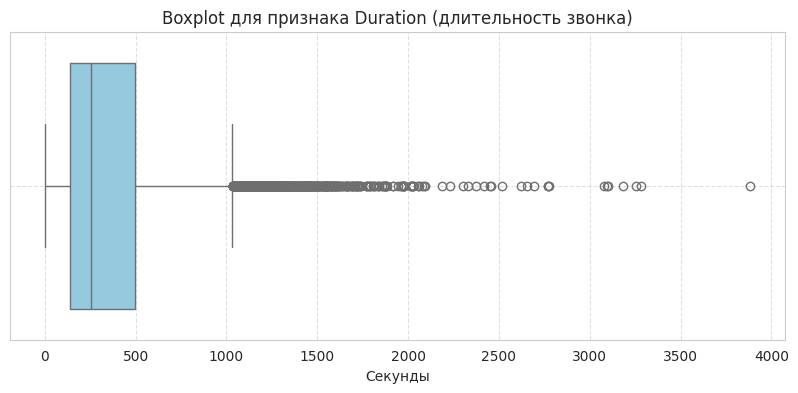

99-й перцентиль: 1577.17 сек.
Максимальное значение (выброс): 3881 сек.


In [14]:
# Задание 4. Визуализация выбросов duration
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['duration'], color='skyblue')
plt.title('Boxplot для признака Duration (длительность звонка)')
plt.xlabel('Секунды')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

q99 = df['duration'].quantile(0.99)
max_val = df['duration'].max()
print(f"99-й перцентиль: {q99:.2f} сек.")
print(f"Максимальное значение (выброс): {max_val} сек.")

### ЗАДАНИЕ 4. Выброс — это ошибка или сигнал?

**1. Реальные причины значения (например, звонок > 3000 сек):**
* **Сигнал:** Длительные успешные переговоры, подробная консультация клиента по сложному продукту (депозиту), которая привела к сделке.
* **Ошибка:** Технический сбой (забыли положить трубку) или человеческий фактор (ошибка фиксации времени звонка оператором).

**2. Что хуже для анализа:**
* **Удалить:** Плохо, так как мы теряем данные о самых лояльных или заинтересованных клиентах.
* **Оставить без изменений:** Плохо для линейных моделей, так как один звонок в 50 минут сместит веса сильнее, чем сотни обычных звонков.
* **Применить преобразование:** Это **лучший вариант**. Логарифмирование или корень позволяют сохранить информацию о факте долгого звонка, но уменьшают его «разрывное» влияние на модель.

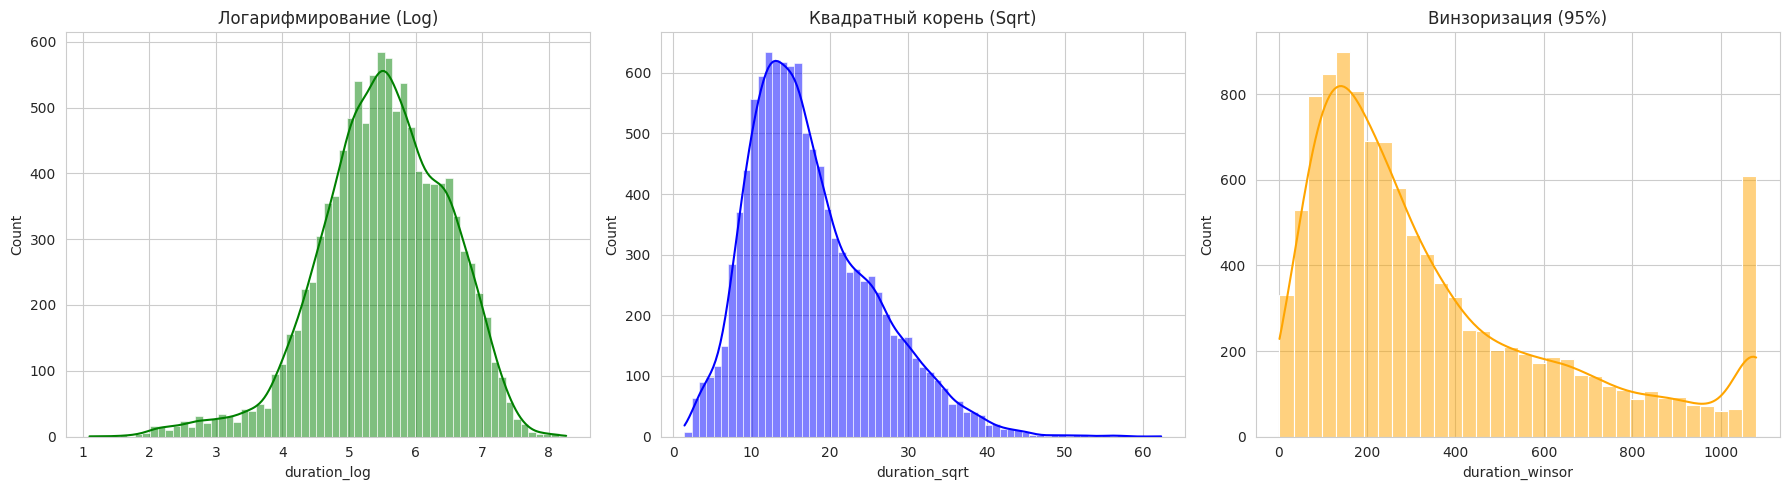

In [15]:
# Задание 5. Сравнение преобразований
df['duration_log'] = np.log1p(df['duration'])
df['duration_sqrt'] = np.sqrt(df['duration'])
p95 = df['duration'].quantile(0.95)
df['duration_winsor'] = df['duration'].clip(upper=p95)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['duration_log'], kde=True, ax=axes[0], color='green').set_title('Логарифмирование (Log)')
sns.histplot(df['duration_sqrt'], kde=True, ax=axes[1], color='blue').set_title('Квадратный корень (Sqrt)')
sns.histplot(df['duration_winsor'], kde=True, ax=axes[2], color='orange').set_title('Винзоризация (95%)')
plt.tight_layout()
plt.show()

### ЗАДАНИЕ 5. Преобразование или винзоризация?

**1. Когда подходы предпочтительнее:**
* **Логарифмирование:** Когда данные имеют «длинный хвост» и мы хотим максимально приблизить распределение к нормальному.( лучший для нас)
* **Корень:** Для умеренной асимметрии; действует мягче логарифма.
* **Винзоризация:** Когда нужно сохранить исходные единицы измерения (секунды) и просто ограничить влияние экстремальных ошибок.

**2. Влияние на показатели:**
* **Интерпретируемость:** Винзоризация сохраняет смысл данных. Log/Sqrt данные сложно объяснять в реальных единицах времени.
* **Линейные модели:** Преобразования (Log/Sqrt) значительно улучшают работу моделей, стабилизируя дисперсию.
* **Визуализация:** Логарифм создает компактный «колокол», винзоризация оставляет хвост, но обрезает его резким «пиком» на границе.


Арифметическое среднее: 1528.54
Медиана: 550.00
Геометрическое среднее: 1218.16


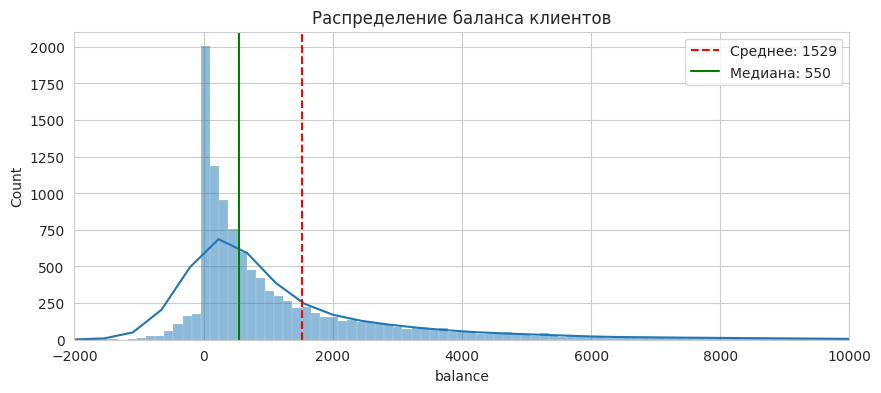

In [16]:
# Задание 6. Анализ среднего для balance
mean_val = df['balance'].mean()
median_val = df['balance'].median()

# Геометрическое среднее со смещением (т.к. баланс может быть < 0)
offset = abs(df['balance'].min()) + 1
g_mean = stats.gmean(df['balance'] + offset) - offset

print(f"Арифметическое среднее: {mean_val:.2f}")
print(f"Медиана: {median_val:.2f}")
print(f"Геометрическое среднее: {g_mean:.2f}")

# Визуализация для подтверждения выводов
plt.figure(figsize=(10, 4))
sns.histplot(df['balance'], kde=True)
plt.axvline(mean_val, color='red', linestyle='--', label=f'Среднее: {mean_val:.0f}')
plt.axvline(median_val, color='green', linestyle='-', label=f'Медиана: {median_val:.0f}')
plt.title('Распределение баланса клиентов')
plt.legend()
plt.xlim(-2000, 10000) # Ограничим для наглядности
plt.show()

### ЗАДАНИЕ 6. Средние, которые вводят в заблуждение

**1. Почему они различаются:**
Арифметическое среднее (~1528) значительно выше медианы (~550). Это результат **сильной положительной асимметрии**: небольшое число очень богатых клиентов «тянет» среднее вверх, хотя у большинства баланс гораздо ниже.

**2. Что лучше отражает «типичное» значение:**
Лучше всего отражает реальность **медиана**. Она устойчива к выбросам-миллионерам. Если мы скажем, что средний баланс 1528, мы обманем отдел маркетинга, так как у половины клиентов на счету менее 550 единиц. Медиана дает объективную картину благосостояния типичного вкладчика.

### ЗАДАНИЕ 7. Неправильная диаграмма

Для анализа выберем визуализацию распределения признака `duration` (длительность звонка). В Задании 4 мы использовали **Boxplot** и **Гистограмму**, чтобы увидеть форму распределения и выбросы.

**1. Худший тип диаграммы для этих данных:**
Худшим выбором для `duration` была бы **Круговая диаграмма (Pie Chart)**.

**2. Какую информацию она бы исказила:**
* **Потеря структуры:** Признак `duration` имеет сотни уникальных значений (от 0 до 5000 секунд). Круговая диаграмма превратилась бы в нечитаемую «кашу» из сотен микроскопических секторов.
* **Скрытие асимметрии:** Мы бы полностью потеряли понимание того, что данные имеют «длинный хвост». Круговая диаграмма не показывает плотность и порядок распределения.

**3. Неверный вывод зрителя:**
Зритель мог бы сделать ложный вывод, что «каждое время звонка встречается одинаково редко», не заметив, что подавляющее большинство звонков сосредоточено в диапазоне до 500 секунд. Смысл выбросов был бы полностью утерян.

/tmp/ipykernel_8374/1661994439.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='deposit', y='age', data=df_plot, ax=axes[0], palette='Set2')


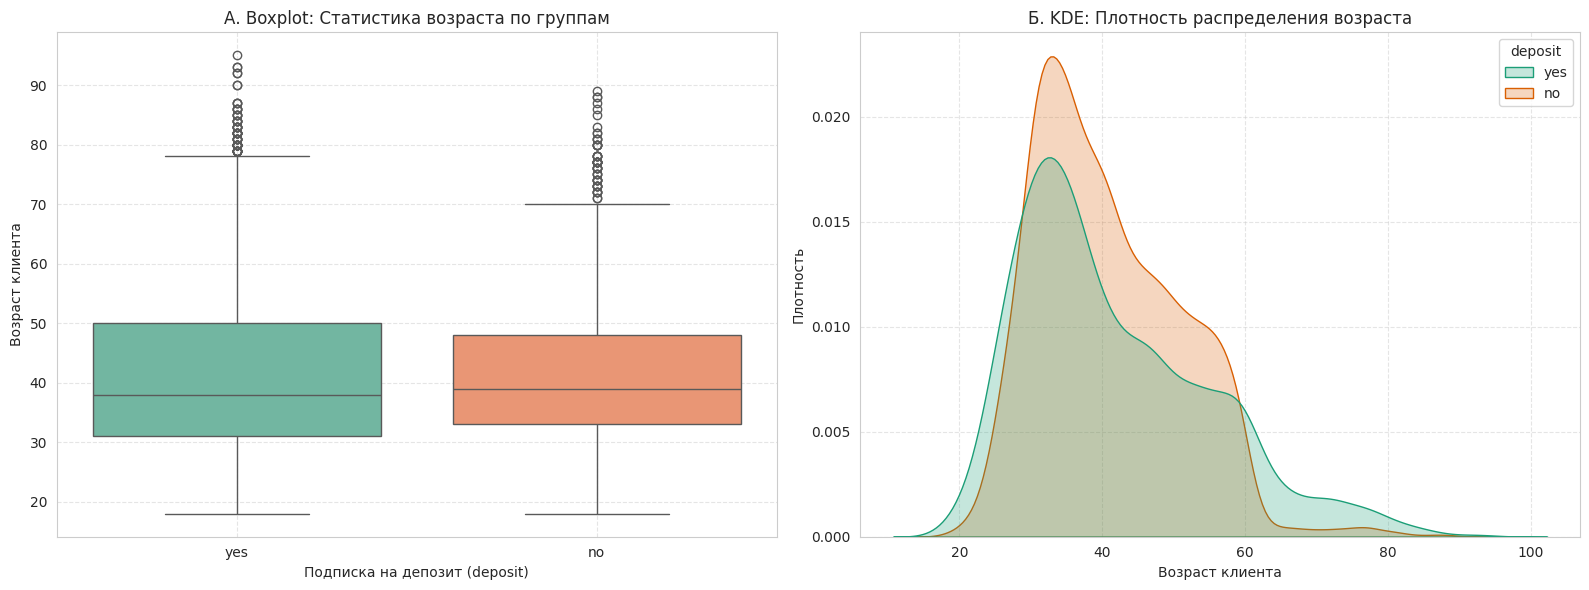

In [21]:
# ===========================================
# ЗАДАНИЕ 8. Подготовка данных и Визуализация
# ===========================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Создаем вспомогательный датафрейм
df_plot = df[['age', 'deposit']].copy()
df_plot['age'] = df_plot['age'].astype(float)

# 2. Построение графиков
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Вариант А: Boxplot
sns.boxplot(x='deposit', y='age', data=df_plot, ax=axes[0], palette='Set2')
axes[0].set_title('А. Boxplot: Статистика возраста по группам')
axes[0].set_xlabel('Подписка на депозит (deposit)')
axes[0].set_ylabel('Возраст клиента')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Вариант Б: KDE-plot
sns.kdeplot(data=df_plot, x='age', hue='deposit', fill=True, ax=axes[1], palette='Dark2')
axes[1].set_title('Б. KDE: Плотность распределения возраста')
axes[1].set_xlabel('Возраст клиента')
axes[1].set_ylabel('Плотность')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### ЗАДАНИЕ 8. Одна и та же информация — разные графики

Для анализа связи возраста и готовности открыть депозит мы использовали одну пару признаков (`age` и `deposit`), представив их двумя способами: группированным **Boxplot** и графиком плотности **KDE**.

**1. Какую информацию подчёркивает каждый график:**
* **Boxplot (Ящик с усами):** Акцентирует внимание на **статистической устойчивости**. Он чётко показывает медианный возраст, межквартильный размах (типичный возраст 50% клиентов) и наличие экстремальных выбросов. На нём легче всего увидеть, есть ли значимый сдвиг центральной тенденции между группами.
* **KDE-plot (График плотности):** Подчеркивает **форму распределения** и **вероятностную массу**. Он наглядно демонстрирует, в каких возрастных интервалах находится «пик» активности клиентов и как эти «волны» накладываются друг на друга для разных целевых групп.

**2. Какие гипотезы легче заметить:**
* **В Boxplot:** Легче заметить гипотезу о наличии **аномального поведения** возрастных групп. Например, наличие множества точек-выбросов в обеих категориях (клиенты 70-90 лет) говорит о том, что возрастные клиенты — это редкие, но существующие случаи в базе.
* **В KDE-plot:** Легче заметить гипотезу о **многомодальности** (наличии нескольких пиков). Если бы банк был популярен одновременно у студентов и пенсионеров, на KDE мы бы увидели два «горба», тогда как Boxplot просто показал бы один очень широкий и неинформативный ящик.